<a href="https://colab.research.google.com/github/slover1126/slover1126/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_5%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**5장 서포트 벡터 머신**

**5.1 선형 SVM 분류**



*   서포트 벡터 머신: 분류의 경계선을 찾되, 그 경계 주변의 공간(마진)을 가장 크게 만드는 선을 찾는 모델
*   이때, 경계에 위치한 샘플들(서포트 벡터)들에 의해 경계가 결정이 됨(다른 샘플은 영향X)
* SVM은 특성의 스케일에 민감하기 때문에 StandardScaler를 사용하는것이 좋음 (한쪽의 단위가 너무 크면 왜곡이 발생)


**5.1.1 소프트 마진 분류**



*   **하드 마진 분류**:모든 샘플이 마진(경계 도로 폭) 밖으로 존재하게 분류함.  이상치가 있는경우 결정경계 계산이 안되거나 결정경계가 이상하게 생길 수 있다는 문제 발생
*   따라서 **소프트 마진 분류** 을 통해서 도로의 폭을 넓게 유지하는 것과 마진 오류(1번 클래스 데이터가 2번 클래스 쪽 결정경계 안에 위치하거나 마진 안에 있는 경우) 사이의 적절한 균형을 찾는것이 중요함
* 이때 **하이퍼파라미터 'C'** 가 사용됨. C를 줄이면 도로가 커지고 마진오류 발생이 증가함. 반대로 늘리면 포함되는 서포트 벡터가 감소해서 마진오류 발생이 감소함. 다만 각각 과소적합, 과대적합 발생 위험을 내포함(모델이 단순/복잡 해지므로)



In [ ]:
from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", 'petal width (cm)']].values
y = (iris.target == 2) #iris-virginica

#스케일링까지 한번에 파이프라인으로 구조화
svm_clf = make_pipeline(StandardScaler(), LinearSVC(C=1, dual = True, random_state=42))

svm_clf.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, dual=True, random_state=42))])

In [ ]:
X_new = [[5.5,1.7], [5.0, 1.5]]
svm_clf.predict(X_new)
#첫 번째 꽃은 True(iris-virginica)로 분류되지만 2번째는 False(iris-virginica이 아님)으로 분류됨

array([ True, False])

In [ ]:
svm_clf.decision_function(X_new)
# array의 첫번째 양수->True로 예

array([ 0.66163411, -0.22036063])

SVM에서 decision_function이 뱉는 숫자는 기준선이 아주 명확합니다.

0 (중앙선): 결정 경계 딱 그 자체입니다.

양수 ($> 0$): True (1번 클래스, iris-virginica)로 예측합니다.

음수 ($< 0$): False (0번 클래스, iris-virginica 아님)로 예측합니다.

+1 과 -1 (가드레일/마진): 서포트 벡터들이 위치한 도로 양쪽 가장자리입니다.

+1보다 크거나 -1보다 작으면: 도로 밖 안전지대에 잘 들어간 데이터입니다.

-1과 +1 사이의 값: 도로(마진) 내부에 아슬아슬하게 들어와 있는 데이터입니다.

즉, array([ 0.66163411, -0.22036063]) 에서 첫번째 원소는 X_new의 첫번째 원소에 대한 결정경계와의 거리, 두번째 원소는 X_new의 두번째 원소에 대한 결정경계의 거리이고, 둘 다 -1~1 사이의 값을 가지므로 마진 안의 데이터라고 할 수 있다.
다만, 첫번째는 양수이므로 True, 두번째는 음수이므로 False로 분류된다.

**5.2 비선형 SVM 분류**

*   앞서 살펴본 예시는 결정경계를 선형으로 분류할 수 있었던 예시임. 그러나 실제 데이터는 비선형적인 경우도 있어 이를 분류하기 위한 방법이 필요함
*  다항회귀에서와 같이 **1차원 특성인 데이터를 제곱하여 2차원 특성을 만들어** 분류하기도 함


In [ ]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X,y = make_moons(n_samples=100, noise =0.15, random_state=42) #두개의 반달 모양으로 생긴 데이터셋 생성하는 코드

polynomial_svm_clf = make_pipeline(PolynomialFeatures(degree=3), StandardScaler(), LinearSVC(C=10, max_iter=10_000, random_state=42))

polynomial_svm_clf.fit(X,y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, max_iter=10000, random_state=42))])

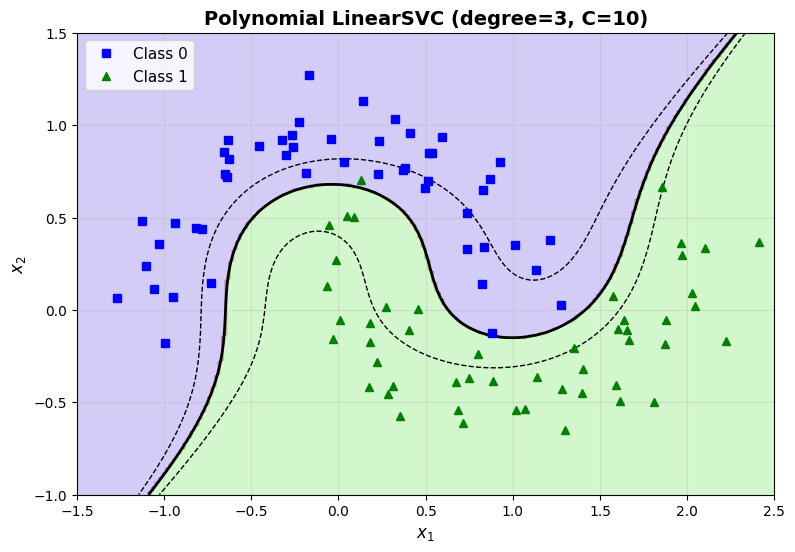

In [ ]:
#시긱화
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC

# 3. 결정 경계 및 마진을 그려주는 함수
def plot_predictions(clf, axes):
  # 격자 그리드 생성
  x0s = np.linspace(axes[0], axes[1], 200)
  x1s = np.linspace(axes[2], axes[3], 200)
  x0, x1 = np.meshgrid(x0s, x1s)
  X_grid = np.c_[x0.ravel(), x1.ravel()]

  # 예측 클래스 및 decision_function 점수 계산
  y_pred = clf.predict(X_grid).reshape(x0.shape)
  y_decision = clf.decision_function(X_grid).reshape(x0.shape)

  # 클래스별 배경색 채우기
  plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

  # 실선: 결정 경계 (0 점수선) / 점선: 마진 경계 (-1, +1 점수선)
  plt.contour(
      x0,
      x1,
      y_decision,
      colors='k',
      levels=[-1, 0, 1],
      linestyles=['--', '-', '--'],
      linewidths=[1, 2, 1],
  )


# 4. 그래프 출력
plt.figure(figsize=(9, 6))

# 결정 경계 및 영역 그리기
plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1.0, 1.5])

# 실제 데이터 포인트 산점도
plt.plot(X[y == 0, 0], X[y == 0, 1], 'bs', label='Class 0')  # 파란 네모
plt.plot(X[y == 1, 0], X[y == 1, 1], 'g^', label='Class 1')  # 초록 세모

plt.title(
    'Polynomial LinearSVC (degree=3, C=10)', fontsize=14, fontweight='bold'
)
plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.axis([-1.5, 2.5, -1.0, 1.5])

plt.show()

**5.2.1 다항식 커널**



*   n차 다항 특성을 추가하면 좋지만, 너무 낮은 n은 데이터를 잘 표현하지 못하고, 너무 높다면 특성이 많아져 모델이 느려지는 문제가 발생함
*   SVM은 **커널 트릭** 이라는 방법을 이용하여 높은 차수의 다항변수를 추가하지 않고 같은 효과를 내게 할수 있음(어떤 특성도 추가하지 않음)



In [ ]:
from sklearn.svm import SVC #커널 기능은 SVC에 있음

poly_kernel_svm_clf = make_pipeline(StandardScaler(), SVC(kernel='poly', degree=3, coef0=1, C=5)) #coef0 은 높은 차수와 낮은 차수에 얼마나 영향을 받을지 정하는 하이퍼파라미

**5.2.2 유사도 특성**

*   비선형 특성을 다루는 또 다른 방법은 **랜드마크** 를 기준으로 이와 얼마나 닮았는지 **유사도 함수**로 계산한 값을 새로운 특성으로 추가하는 방식

*  가장 대표적인 유사도 함수인 가우스 RBF(방사 기저 함수)는 랜드마크일때 1, 멀어질수록 0에 가까워지는 종 모양으로 함수값을 나타냄

*   기존에 분류가 안되는 것들을 유사도 공간으로 보내어 분류가 가능하게 함



*   간단히 모든 샘플 위에 랜드마크를 찍는경우도 있으나 이 경우 특성이 샘플 수만큼 생긴다는 문제가 발생함



*   [1차원 공간: 직선 분류 불가능]


---(A1)-------(B1)-------(A2)--->  (X축)
*  이때, 데이터 $A_1$과 $A_2$ 위치에 랜드마크 $\ell_1, \ell_2$를 지정하고 2차원 유사도 특성으로 변환해 봅니다.

* $A_1$ 데이터: $\ell_1$과 매우 가까움(유사도 $\approx 1$), $\ell_2$와는 멈(유사도 $\approx 0$) $\rightarrow$ 좌표 $(1, 0)

* $A_2$ 데이터: $\ell_1$과 멈(유사도 $\approx 0$), $\ell_2$와 매우 가까움(유사도 $\approx 1$) $\rightarrow$ 좌표 $(0, 1)

* $B_1$ 데이터: 두 랜드마크 모두와 적당히 멀거나 어중간함 $\rightarrow$ 좌표 $(0.1, 0.1)$

* 이렇게 좌표로 2차원 평면으로 이동시켜 분류 가능



**5.2.3 가우스 RBF 커널**


*   다항 특성 방식과 마찬가지로 유사도 특성도 비선형 분류에 유용함
*   이때 유사도 함수는 주로 가우스 방사 기저 함수(RBF)를 쓰고 커널 트릭을 통해 유사도 특성을 많이 추가하는 효과를 낼수있음


*   가우스 RBF 커널 외에도 문자열 커널(텍스트,DNA 분류 특화)과 같은 다른 커널들이 있지만 거의 사용되지 않음




In [ ]:
rbf_kernel_svm_clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma=5, C=0.001))
rbf_kernel_svm_clf.fit(X,y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

**5.2.4 계산 복잡도**

<div style="font-size: 18px; line-height: 1.6;">

<h2>5.2.4 계산 복잡도</h2>

<table style="font-size: 18px; width: 100%; border-collapse: collapse; text-align: center;">
  <thead>
    <tr style="background-color: #2e2e2e; color: #ffffff;">
      <th style="padding: 10px;">파이썬 클래스</th>
      <th style="padding: 10px;">시간 복잡도</th>
      <th style="padding: 10px;">외부 메모리 학습 지원</th>
      <th style="padding: 10px;">스케일 조정의 필요성</th>
      <th style="padding: 10px;">커널 트릭</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 10px;"><b>LinearSVC</b></td>
      <td style="padding: 10px;"><i>O(m × n)</i></td>
      <td style="padding: 10px;">아니오</td>
      <td style="padding: 10px;">예</td>
      <td style="padding: 10px;">아니오</td>
    </tr>
    <tr>
      <td style="padding: 10px;"><b>SVC</b></td>
      <td style="padding: 10px;"><i>O(m² × n) ~ O(m³ × n)</i></td>
      <td style="padding: 10px;">아니오</td>
      <td style="padding: 10px;">예</td>
      <td style="padding: 10px;"><b>예</b></td>
    </tr>
    <tr>
      <td style="padding: 10px;"><b>SGDClassifier</b></td>
      <td style="padding: 10px;"><i>O(m × n)</i></td>
      <td style="padding: 10px;"><b>예</b></td>
      <td style="padding: 10px;">예</td>
      <td style="padding: 10px;">아니오</td>
    </tr>
  </tbody>
</table>

</div>



*   LinearSVC의 경우 데이터가 많아져도 실행시간이 선형적으로만 늘어나서 데이터가 많을때 유용(수행시간은 사이킷런 tol 로 조정)

*   SVC는 커널트릭이 되지만 샘플이 많으면 기하급수적으로 올라가 중소규모 데이터에 적합

*   경사 하강법을 사용하므로 데이터를 조금씩 조각내어 학습(미니배치/점진적 학습)할 수 있어, 데이터가 너무 커서 RAM 용량을 초과할 때(외부 메모리 학습) 적합



**5.3 SVM 회귀**



*   SVM 분류는 마진 안으로 들어오지 못하게 마진오류를 최소화 함
*   반대로 SVM 회귀는 일정 마진 안에서 회대한의 샘플이 들어오도록 함(중앙선 +- 입실론)
*   하이퍼 파라미터는 입실론과 C를 사용
*   입실론이 작아지면 서포트벡터 수가 늘어나서 모델이 규제, 커지면 늘어나서 규제가 줄어듦
*   C(벌점)가 작아지면 벌점(마진 밖에 있는 애들에 대한 벌점)이 약한것이니 선이 적당히 구부러지게 그려짐 C가 커지면 벌점이 커져 이를 최소화 하고자 선이 복잡해짐



In [ ]:
from sklearn.svm import LinearSVR
X,y = #데이터

svm_reg = make_pipeline(StandardScaler(), LinearSVR(epsilon=0.5, random_state=42))
svm_reg.fit(X,y)

In [ ]:
#다차원인 경우 커널트릭 이용(C를 통해 규제 정도 조절)

from sklearn.svm import SVR
X,y = #데이터

svm_poly_reg = make_pipeline(StandardScaler(), SVR(kernel ='poly' , degree =2, C=0.01, epsilon=0.1))
svm_reg.fit(X,y)

**5.4 SVM 이론**

*   SVM은 결정함수를 통해 점수를 산정하고, 점수가 0보다 크면 1(양성), 그렇지 않으면 0(음성) 클래스가 됨


*   결정함수는 다음과 같이 정의됨   $$\boldsymbol{\theta}^T\mathbf{x} = \ b + \theta_1 x_1 + \cdots + \theta_n x_n \quad$$


*   이때 $\mathbf{x}$ : 내가 입력한 데이터(관측치의 변수별 값)


*   $\mathbf{\theta_{i}}$ : 각 특성의 중요도(가중치)
*   $b$: 기본 점수를 의미한다(편향)



*   이 점수가 0보다 크면 1(양성) 작으면 0(음성), 0이면 직선 위에 있음을 의미




**가중치 벡터와 마진의 관계**



*   **가중치 벡터가 작아지면 마진은 커지고, 반대로 가중치 벡터가 커지면 마진(가드레일 위치)은 작아진다.**
*   (예시) 경계룰 -1,1 로 가정하자.(특성이 1개라 가정)

*   가중치가 w= 0.1인 경우 x값이 -10,10 일때 가드레일(마진 끝) 이 됨(1=w*x or -1=w*x 이므로)
*   가중치가 w= 1인 경우 x값은 -1,1 일떄 가드레일(마진 끝)이 됨 (1=w*x or -1=w*x 이므로)


*   가중치가 커지면 목표 마진 임계점까지 필요한 x의 범위가 줄어들고, 가중치가 작아지면 목표 마진 임계점까지 필요한 x의 범위가 늘어난다고 생각하기






**하드 마진과 소프트 마진**
*   하드 마진의 경우 분류 기준을 다음과 같이 표기
*    $t^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)} + b) \ge 1$
*   $t^{(i)}$ 는 실제 정답으로 1,-1 의 값을 가짐 $(\mathbf{w}^T\mathbf{x}^{(i)} + b)$은 결정점수로 0보다 크거나 0보다 작음-> 이 둘이 만나서 잘 분류가 된 경우는 1을 넘는 값이 나옴
* 마진을 최대화 하기 위해서 위의 조건을 만족한 상태에서 $\text{minimize} \quad \frac{1}{2}\mathbf{w}^T\mathbf{w}$ 가 되는 가중치를 찾아야 함



*   소프트 마진의 경우 100% 완벽하게 분류되지 않음을 감수하므로, 떨어진 거리($\zeta$)만큼의 벌금 C를 부과함

*   $\zeta = \max(0, 1 - t \cdot \text{점수})$ 로 정의되며 t는 실제 정답(1,-1)

*   목적함수는 $\text{minimize} \quad \frac{1}{2}\mathbf{w}^T\mathbf{w} + C \sum \zeta$ 와 같이 정의된다.

* 조건)$$t^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)} + b) \ge 1 - \zeta^{(i)}$$
*   제타 만큼 떨어지면 그만큼 C가 증가







*   LinearSVC는 제곱 힌지 손실(멀어질수록 더 큰 손실)
*   SGDClassifier는 힌지 손실을 사용
* 둘 다 loss 라는 하이퍼파라미터를 'hinge', 'squared_hinge' 로 바꿔 손실을 선택할 수 있다.



**5.3 쌍대문제**